In [23]:
import os
import json
import glob
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qaoa_training_pipeline.utils.graph_utils import solve_max_cut, graph_to_operator, load_graph

In [24]:
import os, glob, json, re

def load_json_by_partial_name(partial_name, directory="."):
    pattern = os.path.join(directory, f"*{partial_name}*.json")
    matches = glob.glob(pattern)
    
    if not matches:
        raise FileNotFoundError(f"No JSON files found matching: {partial_name}")
        
    latest = max(
        matches,
        key=lambda s: int(m.group()) if (m := re.search(r"(\d+)$", s)) else -1
    )
    
    with open(latest) as f:
        return json.load(f)


In [29]:
prefix_map = {
    "F": [0, "Fourier", "#EE6677"],
    "FA": [1, "Fixed angles", "#4477AA"],
    "I": [2, "Interp.", "#228833"],
    "LR": [3, "Linear ramp", "#CCBB44"],
    "PT": [4, "Parameter transfer", "#BBBBBB"],
    "RTS": [5, "Recursive TS", "#66CCEE"],
    "TQA": [6, "TQA", "#AA3377"],
}

evaluator_map = {
    "MPS": [0, "MPS (Quimb)", "P"],
    "MPSAer": [1, "MPS (Aer)", "^"],
    "PP": [2, "PP", "s"],
    "SV": [3, "SV", "o"],
}

In [26]:
depth_arr=[2,4,6]
num_instances=10
bond_dim=24
bond_dim2=32
w=4
gn="N144HH73_"
graph_repo="../data/training/heavy_hex"
# gn="N100L2S2_"
# graph_repo="../data/training/line_to_full"
# gn="N70ER20_"
# graph_repo="../data/training/erdos_renyi"
# gn="N40R3R_"
# graph_repo="../data/training/random_regular"
params=['energy', 'train_duration']

In [27]:
shape = (num_instances, len(depth_arr), len(params))

res = {
    "TQA__MPSAer": np.zeros(shape),
    "TQA_*_MPSAer": np.zeros(shape),
    "LR__MPSAer": np.zeros(shape),
    "LR_*_MPSAer": np.zeros(shape),
    "FA_†_MPSAer": np.zeros(shape),
    "FA_*_MPSAer": np.zeros(shape),
    "I_*_MPSAer": np.zeros(shape),
    "F_*_MPSAer": np.zeros(shape),
    "RTS_*_MPSAer": np.zeros(shape),
    "TQA__PP": np.zeros(shape),
    "LR_*_PP": np.zeros(shape),
    "LR__PP": np.zeros(shape),
    "TQA_*_PP": np.zeros(shape),
    "FA_†_PP": np.zeros(shape),
    "FA_*_PP": np.zeros(shape),
    "I_*_PP": np.zeros(shape),
    "F_*_PP": np.zeros(shape),
    "RTS_*_PP": np.zeros(shape),
}

param_idx = {p: i for i, p in enumerate(params)}
depth_to_col = {d: int(d / 2 - 1) for d in depth_arr}

for n in range(num_instances):
    prefix = f"00{n}{gn}MIS_"

    data_I_MPS = load_json_by_partial_name(
        prefix + f"I_MPSAer_optBD{bond_dim}", directory=graph_repo
    )
    data_I_PP = load_json_by_partial_name(
        prefix + f"I_PP_optMW{w}", directory=graph_repo
    )
    data_F_MPS = load_json_by_partial_name(
        prefix + f"F_MPSAer_optBD{bond_dim}", directory=graph_repo
    )
    data_F_PP = load_json_by_partial_name(
        prefix + f"F_PP_optMW{w}", directory=graph_repo
    )
    data_RTS_MPS = load_json_by_partial_name(
        prefix + f"RTS_MPSAer_optBD{bond_dim}", directory=graph_repo
    )
    data_RTS_PP = load_json_by_partial_name(
        prefix + f"RTS_PP_optMW{w}", directory=graph_repo
    )

    for d in depth_arr:
        col = depth_to_col[d]

        data_TQA_MPS = load_json_by_partial_name(
            prefix + f"TQA_MPSAer_optBD{bond_dim}_{d}", directory=graph_repo
        )
        data_TQA_PP = load_json_by_partial_name(
            prefix + f"TQA_PP_optMW{w}_{d}", directory=graph_repo
        )
        data_LR_MPS = load_json_by_partial_name(
            prefix + f"LR_MPSAer_angle_optBD{bond_dim}_{d}", directory=graph_repo
        )
        data_LR_PP = load_json_by_partial_name(
            prefix + f"LR_PP_angle_optMW{w}_{d}", directory=graph_repo
        )
        data_FA_MPS = load_json_by_partial_name(
            prefix + f"FA_MPSAer_optBD{bond_dim}_{d}", directory=graph_repo
        )
        data_FA_PP = load_json_by_partial_name(
            prefix + f"FA_PP_optMW{w}_{d}", directory=graph_repo
        )

        for p, i in param_idx.items():
            res["TQA__MPSAer"][n, col, i] = data_TQA_MPS["0"][p]
            res["TQA_*_MPSAer"][n, col, i] = data_TQA_MPS["1"][p]

            res["LR__MPSAer"][n, col, i] = data_LR_MPS["0"][p]
            res["LR_*_MPSAer"][n, col, i] = data_LR_MPS["1"][p]

            res["FA_†_MPSAer"][n, col, i] = data_FA_MPS["0"][p]
            res["FA_*_MPSAer"][n, col, i] = data_FA_MPS["1"][p]

            res["TQA__PP"][n, col, i] = data_TQA_PP["0"][p]
            res["TQA_*_PP"][n, col, i] = data_TQA_PP["1"][p]

            res["LR__PP"][n, col, i] = data_LR_PP["0"][p]
            res["LR_*_PP"][n, col, i] = data_LR_PP["1"][p]

            res["FA_†_PP"][n, col, i] = data_FA_PP["0"][p]
            res["FA_*_PP"][n, col, i] = data_FA_PP["1"][p]

            res["I_*_MPSAer"][n, col, i] = data_I_MPS["2"][str(d)][p]
            res["I_*_PP"][n, col, i] = data_I_PP["2"][str(d)][p]

            res["F_*_MPSAer"][n, col, i] = data_F_MPS["2"][str(d)][p]
            res["F_*_PP"][n, col, i] = data_F_PP["2"][str(d)][p]

            res["RTS_*_MPSAer"][n, col, i] = data_RTS_MPS["1"][str(d)][p]
            res["RTS_*_PP"][n, col, i] = data_RTS_PP["1"][str(d)][p]

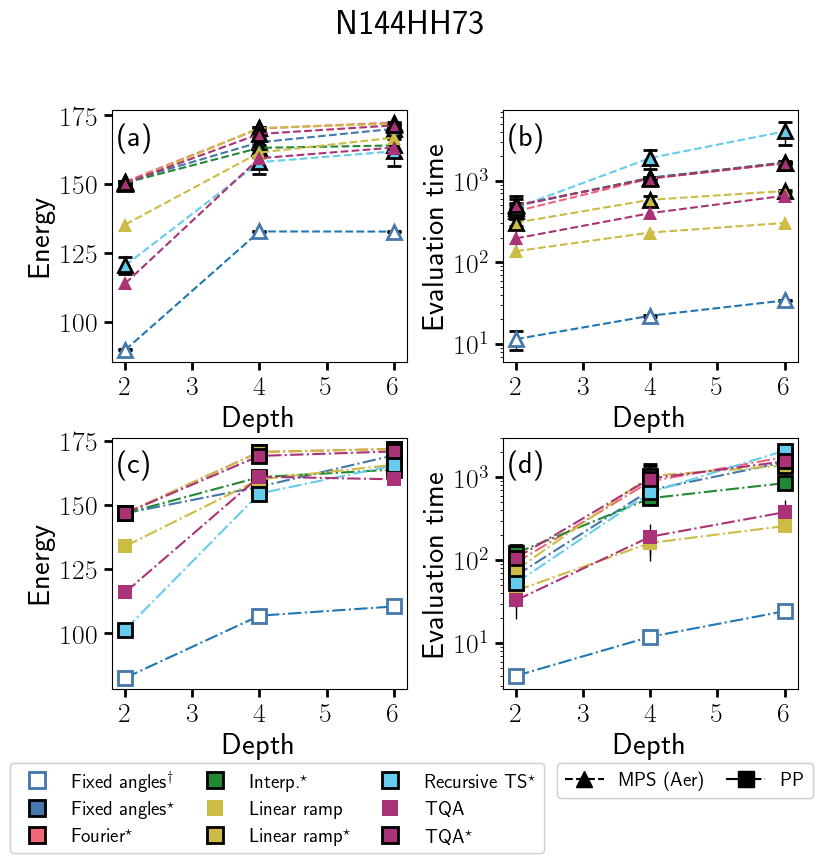

In [30]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

plt.rcParams["text.usetex"] = True
# plt.rcParams["legend.fontsize"] = "small"
plt.rcParams["legend.columnspacing"] = 1
# plt.rcParams["axes.titlesize"] = "small"
# plt.rcParams["axes.labelsize"] = "small"
# plt.rcParams["figure.labelsize"] = "small"
# plt.rcParams["xtick.labelsize"] = "small"
# plt.rcParams["ytick.labelsize"] = "small"

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
depth = depth_arr
depth2 = range(2, 6)

opts = {
    "ecolor": "k",
    "capsize": 5,
    "capthick": 2,
    "elinewidth": 1,
    "ms": 10,
    "linestyle": "--",
}

opts2 = {
    "ecolor": "k",
    "capsize": 5,
    "capthick": 2,
    "elinewidth": 1,
    "ms": 10,
    "linestyle": "-.",
}
labels = ['Energy', 'Evaluation time']

def plot_res(ax, x, arr, j, opt, style):
    ax.errorbar(
        x,
        np.mean(arr[:, :, j], axis=0),
        yerr=np.std(arr[:, :, j], axis=0),
        label="_nolegend_",
        **opt,
        **style
    )
    
def style_scatter(method: str) -> dict:
    """Return a style dictionary suitable for :fun:`matplotlib.pyplot.scatter`.

    Args:
        method: The method label, with ``"*"`` or ``"†"`` if the method is
            optimised or unoptimised.
        evaluation: The energy evaluation method label, e.g., ``"SV"``, ``"MPS
            (Aer)"``, ``"MPS (Quimb)"``, or ``"PP"``.

    Returns:
        A dictionary of kwargs appropriate for matplotlib's scatter function.
    """
    # Configure marker styling based on optimization status:
    # - "*" (optimized angles): black edge, colored fill
    # - "†" (unoptimized): colored edge, white fill
    # - neither: no edge, colored fill
    parts = method.split('_') 
    return {
        "mec": "k"
        if "*" in method
        else (prefix_map[parts[0]][2] if "†" in method else None),
        "marker": evaluator_map[parts[2]][2],
        "color": prefix_map[parts[0]][2] if "†" not in method else None,
        "mfc": "w" if "†" in method else prefix_map[parts[0]][2],
        "markeredgewidth": 2 if ("*" in method or "†" in method) else 0,

    }
    
def style_plot(method: str) -> dict:
    # Configure marker styling based on optimization status:
    # - "*" (optimized angles): black edge, colored fill
    # - "†" (unoptimized): colored edge, white fill
    # - neither: no edge, colored fill
    parts = method.split('_') 
    return {
        "markeredgecolor": "k"
        if "*" in method
        else (prefix_map[parts[0]][2] if "†" in method else None),
        "marker": evaluator_map[parts[2]][2],
        "color": prefix_map[parts[0]][2] if "†" not in method else None,
        "markerfacecolor": "w" if "†" in method else prefix_map[parts[0]][2],
        "markeredgewidth": 2 if ("*" in method or "†" in method) else 0,

    }

def label_maker(method: str):
    parts = method.split('_') 
    suffix = (
        parts[1]
        .replace("*", r"$^{\star}$")
        .replace("†", r"$^{\dagger}$")
    )
    return f"{prefix_map[parts[0]][1]}{suffix}"
    
mps_keys = [
    "FA_†_MPSAer",
    "FA_*_MPSAer",
    "F_*_MPSAer",
    "I_*_MPSAer",
    "LR__MPSAer",
    "LR_*_MPSAer",
    "RTS_*_MPSAer",
    "TQA__MPSAer",
    "TQA_*_MPSAer",
]

pp_keys = [
    "FA_†_PP",
    "FA_*_PP",
    "F_*_PP",
    "I_*_PP",
    "LR__PP",
    "LR_*_PP",
    "RTS_*_PP",
    "TQA__PP",
    "TQA_*_PP",
]

for j, label in enumerate(labels):

    for key in mps_keys:
        style = style_scatter(key)
        plot_res(axs[0][j], depth, res[key], j, opts, style)

    axs[0][j].set_ylabel(label, fontsize=22)
    axs[0][j].set_xlabel("Depth", fontsize=22)

    for key in pp_keys:
        style = style_scatter(key)
        plot_res(axs[1][j], depth, res[key], j, opts2, style)

    axs[1][j].set_ylabel(label, fontsize=22)
    axs[1][j].set_xlabel("Depth", fontsize=22)
axs[0][1].set_yscale("log")
axs[1][1].set_yscale("log")

for ax in axs.ravel():
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(
            axis='both',
            labelsize=20,
            width=2,
            length=6
        )

# ----------------------------
# Legend 1: colors from prefix_map
# prefix_map[prefix] = (display_name, color_index)
# ----------------------------
color_handles = [
    Line2D(
        [0], [0],
        linestyle='None',
        markersize=12,
        **style_plot(key),
        label=label_maker(key)
    )
    for key in pp_keys
]

# ----------------------------
# Legend 2: markers for the two families
# ----------------------------
marker_handles = [
    Line2D(
        [0], [0],
        marker='^',
        linestyle="--",
        markersize=12,
        color='k',
        markerfacecolor='k',
        markeredgecolor='k',
        label='MPS (Aer)'
    ),
    Line2D(
        [0], [0],
        marker='s',
        linestyle="-.",
        markersize=12,
        color='k',
        markerfacecolor='k',
        markeredgecolor='k',
        label='PP'
    )
]

# place legends side by side
leg1 = fig.legend(
    handles=color_handles,
    loc="upper center",
    bbox_to_anchor=(0.33, 0.12),
    ncol=min(3, len(color_handles)),
    frameon=True,
    fontsize=14,
)

leg2 = fig.legend(
    handles=marker_handles,
    loc="upper center",
    bbox_to_anchor=(0.84, 0.12),
    ncol=2,
    frameon=True,
    fontsize=14,
)

fig.add_artist(leg1)
fig.add_artist(leg2)

fig.suptitle(gn.rstrip("_"), fontsize=25, y=1.05)

subplot_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]

for ax, subplot_label in zip(axs.ravel(), subplot_labels):
    ax.text(
        0.02, 0.95, subplot_label,
        transform=ax.transAxes,
        fontsize=22,
        va="top",
        ha="left"
    )
    
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)

fig.savefig(f"{gn}mis_E.pdf", bbox_inches="tight")